In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [86]:
# Loading the cleaned dataset
housing = pd.read_csv("housing_cleaned.csv")

# The  first five rows
housing.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [87]:
# Creating a LabelEncoder to convert categorical values into numeric labels.
le = LabelEncoder()

In [88]:
# List of categorical columns
categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

# Applying LabelEncoder to each categorical column
for col in categorical_columns:
    housing[col] = le.fit_transform(housing[col])

In [89]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [90]:
# Features (independent variables)
X = housing.drop("price", axis=1)

# Target (dependent variable)
y = housing["price"]

In [91]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [92]:
# Verifying the split
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (436, 12)
Testing Features: (109, 12)
Training Target: (436,)
Testing Target: (109,)


In [93]:
# The dataset was divided into training (80%) and testing (20%) sets.
# The training set is used to teach the model, while the testing set
# evaluates how well the model performs on unseen data.

In [94]:
# Creating the Linear Regression model
lr_model = LinearRegression()

In [95]:
# Training the model using the training data
lr_model.fit(X_train, y_train)

LinearRegression()

In [96]:
# Predicting house prices using the testing data
y_pred = lr_model.predict(X_test)

In [97]:
# Calculating RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1331071.4167895103


In [98]:
# The model achieved an RMSE of approximately 1.33 million.
# This means the predicted house prices differ from the actual prices by about 1.33 million on average.

In [99]:
# Calculating R-squared
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6494754192267804


In [100]:
# The R² score of 0.649 indicates that approximately 65% of the variation in house prices is explained by the model.

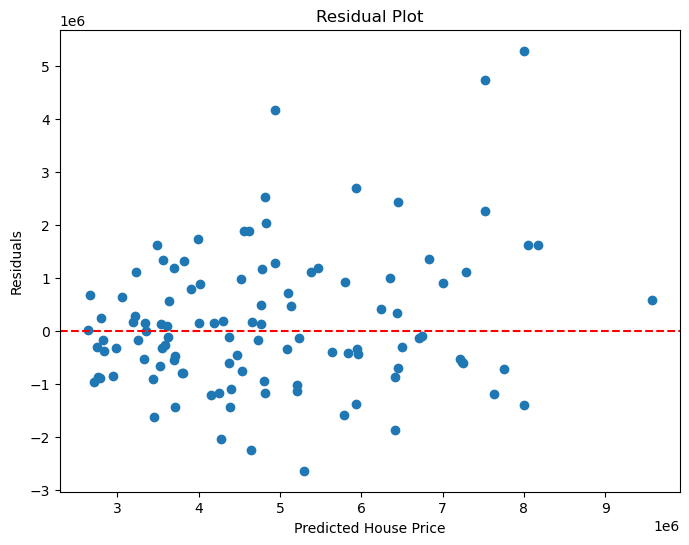

In [101]:
# Calculate residuals
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

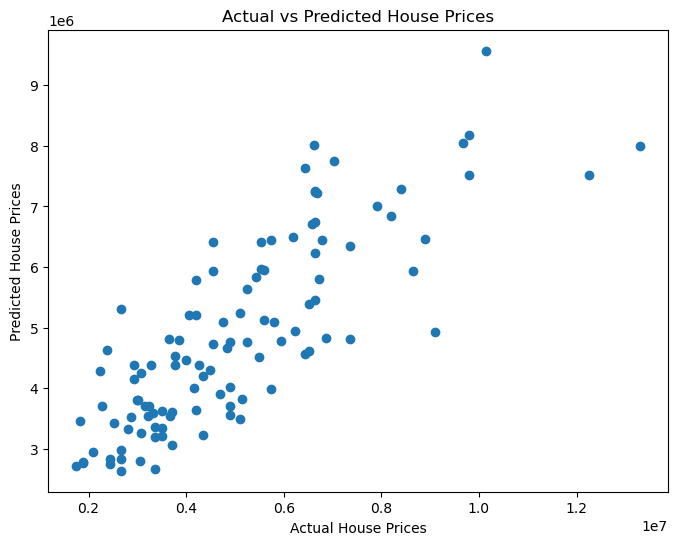

In [102]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [103]:
#Model Evaluation

In [104]:
# Model Type - Linear Regression Model 

# Model Performance Results
# Evaluation Metric
# Root Mean Squared Error (RMSE) - 1,331,071.42
# R² Score	- 0.6495 (64.95%)

# Interpretation
# - The Linear Regression model achieved an RMSE of 1,331,071.42, indicating that its predictions differ from the actual house prices by an average of approximately ₦1.33 million. 
# - The model also obtained an R² score of 0.6495, meaning that about 65% of the variation in house prices is explained by the selected features. 
# - Overall, the model demonstrates good predictive performance and provides a reasonable fit to the data, 
#   although additional features or more advanced models could further improve its accuracy.